# Sensor virtual PM10

*GSDPI, 2026. Universidad de Oviedo*


Este ejemplo muestra la construcción de un
sensor virtual para estimar concentración de PM10 a partir de otras
medidas disponibles (por ejemplo, NO2, CO y variables temporales).

Qué muestra el ejemplo:
- Cómo descargar y convertir un JSON público a `pandas.DataFrame`.
- Preparación de variables temporales (día de la semana, hora, mes).
- Selección de features (`no2`, `co`, `dia_semana`, `hora`, `mes`, `vv`, `dd`)
  y definición del target (`pm10`).
- Preprocesado y normalización con `MinMaxScaler` (rango [-1,1]).
- División reproducible en entrenamiento/prueba con `train_test_split`.
- Entrenamiento de dos modelos: `Ridge` (lineal) y `SVR` (no lineal).
- Evaluación mediante MSE (normalizado y sobre conjunto de prueba).
- Visualización de las predicciones invertidas a la escala original.

Objetivos de aprendizaje:
- Entender flujo completo de un problema de regresión supervisada con datos
  reales: desde la obtención de datos hasta la evaluación y visualización.
- Comparar un modelo lineal (interpretabilidad) frente a un modelo no lineal
  (capacidad para capturar relaciones complejas).
- Discutir buenas prácticas: limpieza, escalado, separación train/test y métricas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import requests
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

%matplotlib inline

## Descarga de datos (JSON)
Usamos `requests` para obtener el JSON público. En entornos sin `requests` se
puede usar `urllib.request` + `json.loads`.

In [2]:
URL_YEAR = "https://opendata.gijon.es/descargar.php?id=24&tipo=JSON"
print('Descargando datos...')
resp = requests.get(URL_YEAR, headers={'User-Agent': 'Mozilla/5.0'}, timeout=15)
resp.raise_for_status()
data_json = resp.json()
print('OK — datos cargados')

Descargando datos...
OK — datos cargados


## Montaje del DataFrame y variables temporales
Explicación: filtramos por estación (ejemplo: estación 1) y combinamos `fecha` + `periodo`.

In [3]:
df = pd.DataFrame(data_json['calidadaires']['calidadaire'])
df = df[df['estacion'] == 1]  # cambiar estación si se desea
df['fecha'] = pd.to_datetime(df['fecha'])
df['hora'] = df['periodo'] - 1  # periodo 1-24 -> hora 0-23
df.index = df['fecha'] + pd.to_timedelta(df['hora'], unit='h')
df = df.sort_index()
df['dia_semana'] = df.index.weekday
df['mes'] = df.index.month
variables = ['no2','co','pm10','dia_semana','hora','mes','vv','dd']
df = df[variables]  # seleccionar solo columnas relevantes
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
print(f'Total muestras: {len(df)}')
df.head(12)

Total muestras: 8549


,no2,co,pm10,dia_semana,hora,mes,vv,dd
2017-01-01 00:00:00,44.0,1.19,38.0,6,0,1,0.11,277.0
2017-01-01 01:00:00,41.0,1.17,35.0,6,1,1,0.11,271.0
2017-01-01 02:00:00,40.0,1.17,36.0,6,2,1,0.10,291.0
2017-01-01 03:00:00,39.0,1.09,31.0,6,3,1,0.11,276.0
2017-01-01 04:00:00,37.0,1.04,22.0,6,4,1,0.12,284.0
2017-01-01 05:00:00,40.0,1.12,32.0,6,5,1,0.11,294.0
2017-01-01 06:00:00,38.0,1.00,21.0,6,6,1,0.10,310.0
2017-01-01 07:00:00,38.0,0.96,20.0,6,7,1,0.11,293.0
2017-01-01 08:00:00,33.0,0.94,20.0,6,8,1,0.13,276.0
2017-01-01 09:00:00,30.0,0.84,15.0,6,9,1,0.15,254.0


### Atributos (features) y etiqueta (target)

- Entradas (`X`): 
    - `no2`, `co`, `dia_semana`, `hora`, `mes`, `vv`, `dd` — variables predictoras que incluyen medidas de otros contaminantes y variables temporales/meteorológicas.

- Etiqueta (`y`): 
    - `pm10` — concentración objetivo de material particulado que se pretende predecir.

## Preprocesado y normalización
Normalizamos en [-1,1] con `MinMaxScaler` para estabilizar modelos.

In [4]:
X = df[['no2','co','dia_semana','hora','mes','vv','dd']].values
y = df['pm10'].values
scaler_X = MinMaxScaler(feature_range=(-1,1))
scaler_y = MinMaxScaler(feature_range=(-1,1))
X_norm = scaler_X.fit_transform(X)
y_norm = scaler_y.fit_transform(y.reshape(-1,1)).ravel()
X_norm.shape, y_norm.shape

((8549, 7), (8549,))

## División entrenamiento / prueba
Usamos `train_test_split` para separar 80/20 de forma reproducible.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)
print(f'Muestras entrenamiento: {len(X_train)}, prueba: {len(X_test)}')

Muestras entrenamiento: 6839, prueba: 1710


## Entrenamiento de modelos
Entrenamos `Ridge` como baseline y `SVR` con kernel RBF para comparativa.

In [6]:
model_ridge = Ridge(fit_intercept=True)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_norm)  # predicción sobre toda la serie

model_svr = SVR(kernel='rbf', gamma=0.5, C=5, epsilon=0.05)
model_svr.fit(X_train, y_train)
y_pred_svr = model_svr.predict(X_norm)

## Evaluación
Calculamos MSE en la escala normalizada. En clase comentar MAE, R2 y evaluación sobre `X_test`/`y_test`.

In [7]:
mse_ridge = np.mean((y_norm - y_pred_ridge) ** 2)
mse_svr   = np.mean((y_norm - y_pred_svr) ** 2)
print('MSE (normalizado)')
print(f'Ridge: {mse_ridge:.5f}')
print(f'SVR  : {mse_svr:.5f}')

# Evaluación adicional: MSE sobre conjunto de prueba (opcional didáctico)
mse_ridge_test = np.mean((y_test - model_ridge.predict(X_test))**2)
mse_svr_test = np.mean((y_test - model_svr.predict(X_test))**2)
print('MSE sobre conjunto de prueba:')
print(f'Ridge (test): {mse_ridge_test:.5f}')
print(f'SVR   (test): {mse_svr_test:.5f}')

MSE (normalizado)
Ridge: 0.01307
SVR  : 0.00902
MSE sobre conjunto de prueba:
Ridge (test): 0.01439
SVR   (test): 0.01096


## Visualización
Mostramos predicciones invertidas a la escala original para interpretación.

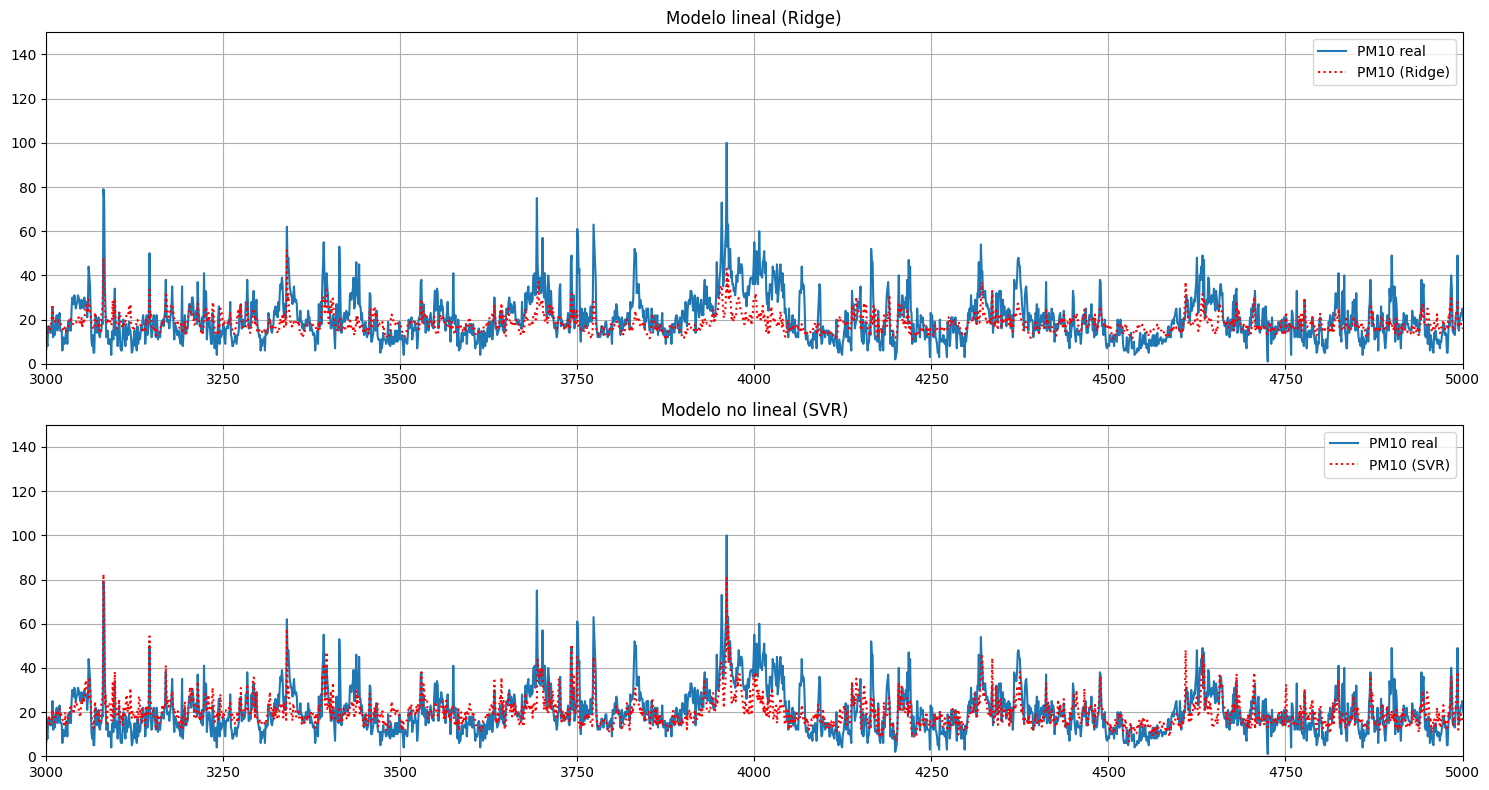

In [8]:
df['pred_ridge'] = scaler_y.inverse_transform(y_pred_ridge.reshape(-1,1))
df['pred_svr'] = scaler_y.inverse_transform(y_pred_svr.reshape(-1,1))

plt.figure(figsize=(15,8))
xmin, xmax = 3000, 5000
ymin, ymax = 0, 150
plt.subplot(2,1,1)
plt.plot(df['pm10'].values, label='PM10 real')
plt.plot(df['pred_ridge'].values, 'r:', label='PM10 (Ridge)')
plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
plt.grid(True); plt.legend(); plt.title('Modelo lineal (Ridge)')

plt.subplot(2,1,2)
plt.plot(df['pm10'].values, label='PM10 real')
plt.plot(df['pred_svr'].values, 'r:', label='PM10 (SVR)')
plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
plt.grid(True); plt.legend(); plt.title('Modelo no lineal (SVR)')

plt.tight_layout()
plt.show()